In [ ]:
# ==============================
# 📦 Install Required Libraries
# ==============================

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost pulp plotly folium tqdm --quiet

print("All libraries installed successfully.")

All libraries installed successfully.


In [ ]:
# ==============================
# 📚 Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from pulp import LpProblem, LpMinimize, LpVariable, lpSum

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ==============================
# 🌍 Load Alternative Public Dataset
# ==============================

url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_usa_states.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully.")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully.
Shape: (52, 4)


,Rank,State,Postal,Population
0,1,Alabama,AL,4849377.0
1,2,Alaska,AK,736732.0
2,3,Arizona,AZ,6731484.0
3,4,Arkansas,AR,2966369.0
4,5,California,CA,38802500.0


In [ ]:
# ==========================================
# 🌍 Generate Synthetic Humanitarian Dataset
# ==========================================

np.random.seed(42)

n_samples = 10000

disaster_types = ['Flood', 'Earthquake', 'Cyclone', 'Wildfire', 'Drought']
regions = ['Asia', 'Africa', 'Europe', 'North America', 'South America']

df = pd.DataFrame({
    "Year": np.random.randint(2005, 2024, n_samples),
    "Region": np.random.choice(regions, n_samples),
    "Disaster_Type": np.random.choice(disaster_types, n_samples),
    "Affected_Population": np.random.randint(1000, 1000000, n_samples),
    "Economic_Damage_Million_USD": np.random.uniform(0.5, 500, n_samples),
})

# Simulate resource demand
df["Food_Demand_Tons"] = df["Affected_Population"] * np.random.uniform(0.002, 0.01, n_samples)
df["Medical_Kits_Required"] = df["Affected_Population"] * np.random.uniform(0.001, 0.005, n_samples)
df["Water_Requirement_Liters"] = df["Affected_Population"] * np.random.uniform(2, 5, n_samples)

# Simulate logistics cost
df["Logistics_Cost"] = df["Economic_Damage_Million_USD"] * np.random.uniform(1000, 5000, n_samples)

print("Synthetic Humanitarian Dataset Created Successfully.")
print("Shape:", df.shape)

df.head()

Synthetic Humanitarian Dataset Created Successfully.
Shape: (10000, 9)


,Year,Region,Disaster_Type,Affected_Population,Economic_Damage_Million_USD,Food_Demand_Tons,Medical_Kits_Required,Water_Requirement_Liters,Logistics_Cost
0,2011,South America,Earthquake,281014,80.276678,2438.159172,660.767884,8.041210e+05,3.723422e+05
1,2019,North America,Cyclone,968051,359.290940,6220.758451,4603.264060,2.759472e+06,1.500690e+06
2,2015,South America,Flood,46738,414.338322,237.715141,91.723285,2.001835e+05,1.738586e+06
3,2012,Asia,Flood,68537,157.361906,566.017511,90.626848,2.414810e+05,3.839473e+05
4,2011,South America,Drought,242015,139.609407,1319.124835,1137.479857,1.059887e+06,4.700372e+05


In [ ]:
# ==========================================
# 🎯 Demand Prediction Model
# ==========================================

# Features & Target
features = df[["Affected_Population", "Economic_Damage_Million_USD"]]
target = df["Food_Demand_Tons"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 1499.8332247763299
Random Forest R2: 0.5461464962063574


In [ ]:
# ==========================================
# 🚀 XGBoost Regression Model
# ==========================================

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 1395.6204877608186
XGBoost R2: 0.6070254501334631


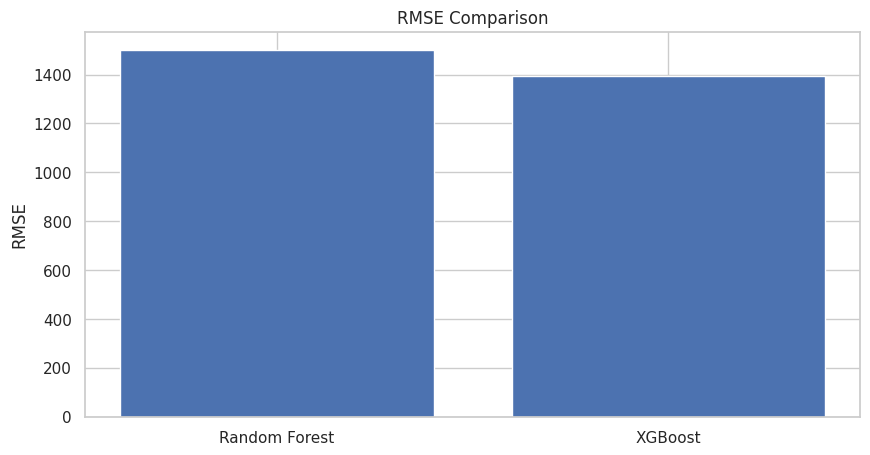

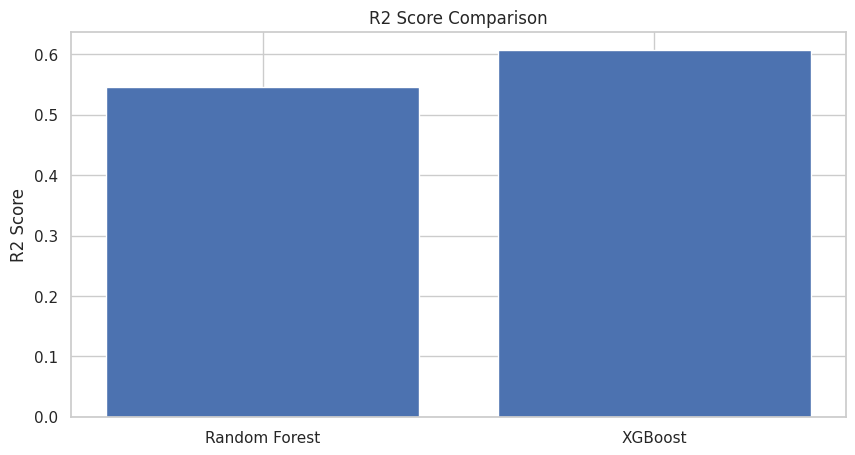

In [ ]:
# ==========================================
# 📊 Model Comparison Visualization
# ==========================================

models = ['Random Forest', 'XGBoost']
rmse_values = [rf_rmse, xgb_rmse]
r2_values = [rf_r2, xgb_r2]

plt.figure(figsize=(10,5))
plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(models, r2_values)
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.show()

In [ ]:
# ==========================================
# 🌍 Crisis Severity Clustering (KMeans)
# ==========================================

cluster_features = df[[
    "Affected_Population",
    "Economic_Damage_Million_USD",
    "Food_Demand_Tons"
]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Crisis_Cluster"] = kmeans.fit_predict(scaled_features)

print("Clustering completed.")
df.head()

Clustering completed.


,Year,Region,Disaster_Type,Affected_Population,Economic_Damage_Million_USD,Food_Demand_Tons,Medical_Kits_Required,Water_Requirement_Liters,Logistics_Cost,Crisis_Cluster
0,2011,South America,Earthquake,281014,80.276678,2438.159172,660.767884,8.041210e+05,3.723422e+05,3
1,2019,North America,Cyclone,968051,359.290940,6220.758451,4603.264060,2.759472e+06,1.500690e+06,2
2,2015,South America,Flood,46738,414.338322,237.715141,91.723285,2.001835e+05,1.738586e+06,0
3,2012,Asia,Flood,68537,157.361906,566.017511,90.626848,2.414810e+05,3.839473e+05,3
4,2011,South America,Drought,242015,139.609407,1319.124835,1137.479857,1.059887e+06,4.700372e+05,3


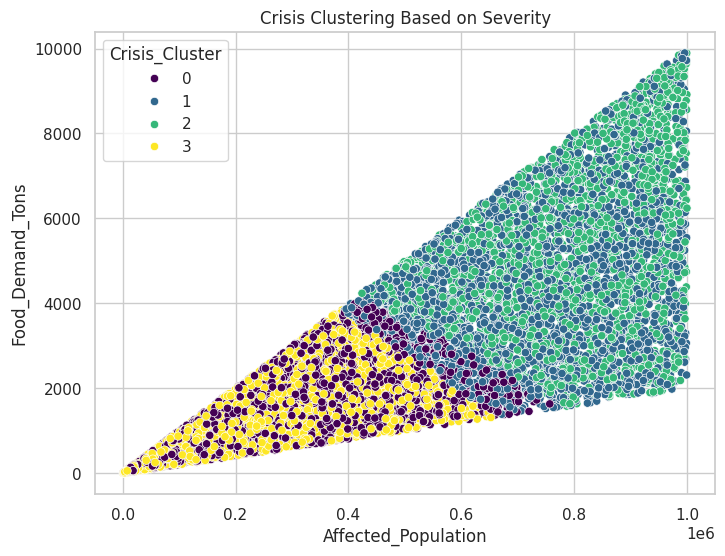

In [ ]:
# ==========================================
# 📊 Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["Affected_Population"],
    y=df["Food_Demand_Tons"],
    hue=df["Crisis_Cluster"],
    palette="viridis"
)
plt.title("Crisis Clustering Based on Severity")
plt.show()

In [ ]:
# ==========================================
# 🧠 Intelligent Resource Allocation Model (Fixed)
# ==========================================

from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus

opt_df = df.sample(50, random_state=42).reset_index(drop=True)

total_available_food = opt_df["Food_Demand_Tons"].sum() * 0.8

problem = LpProblem("Humanitarian_Resource_Allocation", LpMinimize)

# Decision variables
allocation = [
    LpVariable(f"alloc_{i}", lowBound=0)
    for i in range(len(opt_df))
]

# Objective: Minimize total unmet demand (linear form)
problem += lpSum([
    opt_df["Food_Demand_Tons"][i] - allocation[i]
    for i in range(len(opt_df))
])

# Constraint: Allocation cannot exceed demand
for i in range(len(opt_df)):
    problem += allocation[i] <= opt_df["Food_Demand_Tons"][i]

# Constraint: Total supply limit
problem += lpSum(allocation) <= total_available_food

problem.solve()

print("Solver Status:", LpStatus[problem.status])

opt_df["Allocated_Food"] = [allocation[i].varValue for i in range(len(opt_df))]
opt_df["Unmet_Demand"] = opt_df["Food_Demand_Tons"] - opt_df["Allocated_Food"]

print("Optimization Completed Successfully.")
opt_df.head()

Solver Status: Optimal
Optimization Completed Successfully.


,Year,Region,Disaster_Type,Affected_Population,Economic_Damage_Million_USD,Food_Demand_Tons,Medical_Kits_Required,Water_Requirement_Liters,Logistics_Cost,Crisis_Cluster,Allocated_Food,Unmet_Demand
0,2021,North America,Earthquake,47261,391.020301,317.566270,48.015097,2.262232e+05,1.623952e+06,0,317.56627,-4.169596e-08
1,2008,North America,Flood,546336,226.407420,2398.507544,1411.766658,2.191670e+06,3.654789e+05,3,2398.50750,4.388175e-05
2,2015,South America,Cyclone,191286,37.229599,977.459963,882.218127,4.367396e+05,4.477157e+04,3,977.45996,2.567684e-06
3,2015,Africa,Wildfire,925337,227.240318,3587.265569,3176.910308,3.129210e+06,5.672857e+05,1,0.00000,3.587266e+03
4,2007,South America,Wildfire,220322,480.289866,600.984122,681.098150,8.350292e+05,1.683532e+06,0,600.98412,2.200242e-06


In [ ]:
# ==========================================
# 🌍 Social Impact Analysis
# ==========================================

total_demand = opt_df["Food_Demand_Tons"].sum()
total_allocated = opt_df["Allocated_Food"].sum()
total_unmet = opt_df["Unmet_Demand"].sum()

coverage_percentage = (total_allocated / total_demand) * 100

print("Total Demand:", round(total_demand,2))
print("Total Allocated:", round(total_allocated,2))
print("Total Unmet Demand:", round(total_unmet,2))
print("Coverage Percentage:", round(coverage_percentage,2), "%")

Total Demand: 150704.04
Total Allocated: 120563.23
Total Unmet Demand: 30140.81
Coverage Percentage: 80.0 %


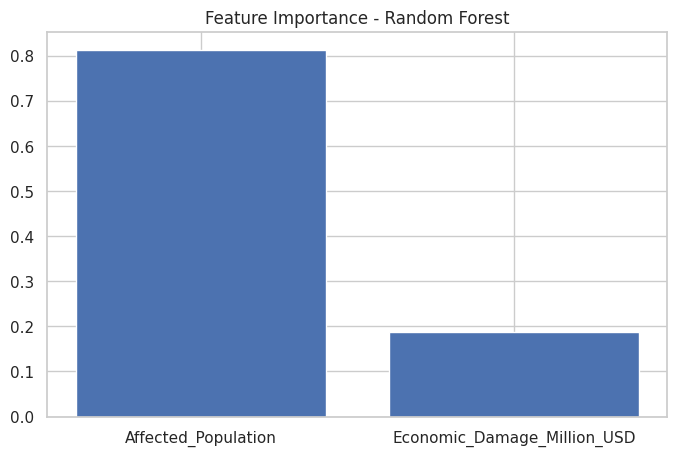

In [ ]:
# ==========================================
# 📊 Feature Importance (Random Forest)
# ==========================================

importances = rf.feature_importances_
feature_names = features.columns

plt.figure(figsize=(8,5))
plt.bar(feature_names, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
# ==========================================
# 📈 Interactive Visualization
# ==========================================

fig = px.scatter(
    df.sample(1000),
    x="Affected_Population",
    y="Food_Demand_Tons",
    color="Region",
    title="Interactive Crisis Severity Visualization"
)

fig.show()